In [1]:
# Temel
import os
import random
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    cohen_kappa_score,
    top_k_accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

# Görsel ayarlar
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")


Kullanılan cihaz: cuda


In [4]:
class Config:
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    N_SPLITS = 5
    RANDOM_STATE = 42

config = Config()


In [5]:
DATASET_DIR = r"C:\Users\Kardelen\Desktop\dlp\garbage-dataset"   # ana veri klasörü


In [6]:
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

num_classes = len(class_names)

print("Sınıflar:")
for i, cls in enumerate(class_names):
    print(f"{i}: {cls}")

print(f"\nToplam sınıf sayısı: {num_classes}")


Sınıflar:
0: battery
1: biological
2: cardboard
3: clothes
4: glass
5: metal
6: paper
7: plastic
8: shoes
9: trash

Toplam sınıf sayısı: 10


In [7]:
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

class_to_idx


{'battery': 0,
 'biological': 1,
 'cardboard': 2,
 'clothes': 3,
 'glass': 4,
 'metal': 5,
 'paper': 6,
 'plastic': 7,
 'shoes': 8,
 'trash': 9}

In [8]:
data = []

for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    for img in images:
        data.append({
            "image_path": os.path.join(cls_path, img),
            "label": class_to_idx[cls],
            "class_name": cls
        })

df = pd.DataFrame(data)
df.head()


,image_path,label,class_name
0,C:\Users\Kardelen\Desktop\dlp\garbage-dataset\...,0,battery
1,C:\Users\Kardelen\Desktop\dlp\garbage-dataset\...,0,battery
2,C:\Users\Kardelen\Desktop\dlp\garbage-dataset\...,0,battery
3,C:\Users\Kardelen\Desktop\dlp\garbage-dataset\...,0,battery
4,C:\Users\Kardelen\Desktop\dlp\garbage-dataset\...,0,battery


In [9]:
class_distribution = (
    df["class_name"]
    .value_counts()
    .reset_index()
)

class_distribution.columns = ["Class", "Image_Count"]
class_distribution


,Class,Image_Count
0,clothes,5327
1,glass,3061
2,plastic,1984
3,shoes,1977
4,cardboard,1825
5,paper,1680
6,metal,1020
7,biological,997
8,trash,947
9,battery,944


In [10]:
print(f"Toplam görüntü sayısı: {len(df)}")
print("\nSınıf bazlı dağılım:")
print(class_distribution)

assert len(df) > 0, "❌ Veri seti boş!"
assert num_classes == class_distribution.shape[0], "❌ Sınıf sayısı tutmuyor!"


Toplam görüntü sayısı: 19762

Sınıf bazlı dağılım:
        Class  Image_Count
0     clothes         5327
1       glass         3061
2     plastic         1984
3       shoes         1977
4   cardboard         1825
5       paper         1680
6       metal         1020
7  biological          997
8       trash          947
9     battery          944


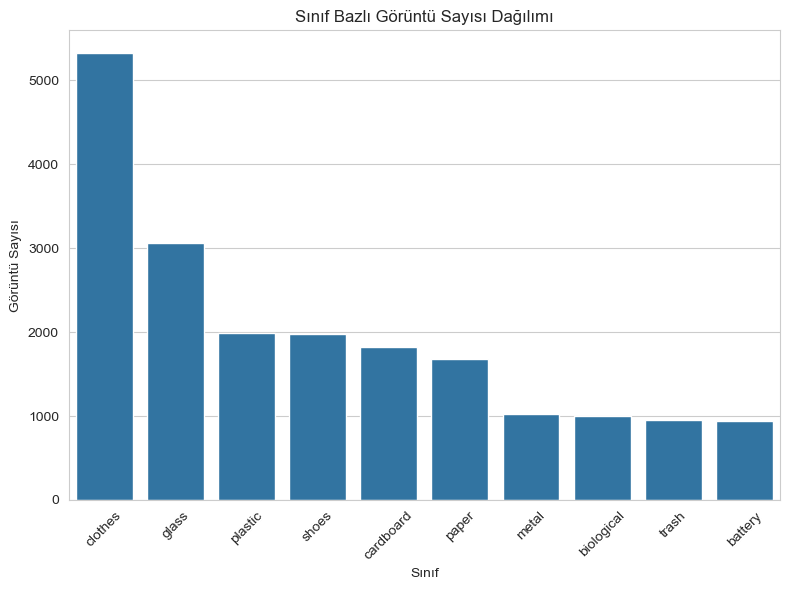

In [11]:
plt.figure()
sns.barplot(
    x="Class",
    y="Image_Count",
    data=class_distribution
)
plt.title("Sınıf Bazlı Görüntü Sayısı Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Görüntü Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


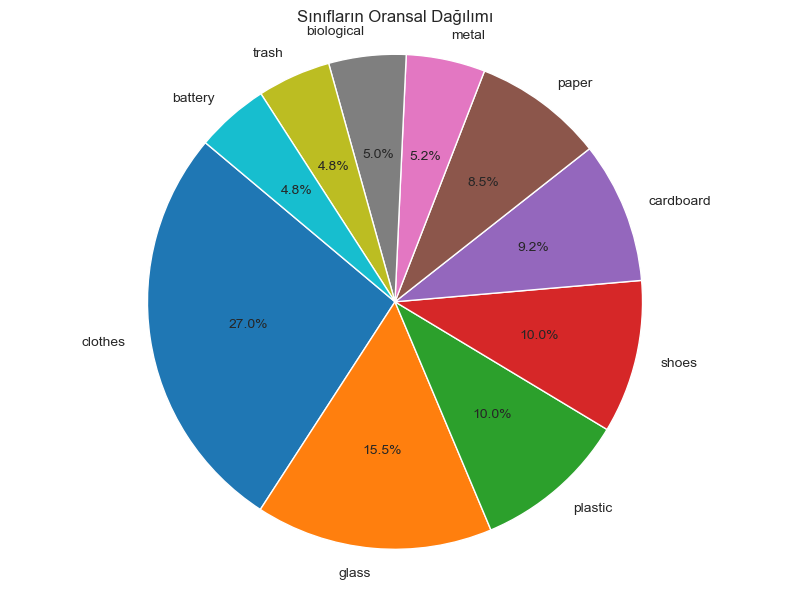

In [12]:
plt.figure()
plt.pie(
    class_distribution["Image_Count"],
    labels=class_distribution["Class"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Sınıfların Oransal Dağılımı")
plt.axis("equal")
plt.tight_layout()
plt.show()


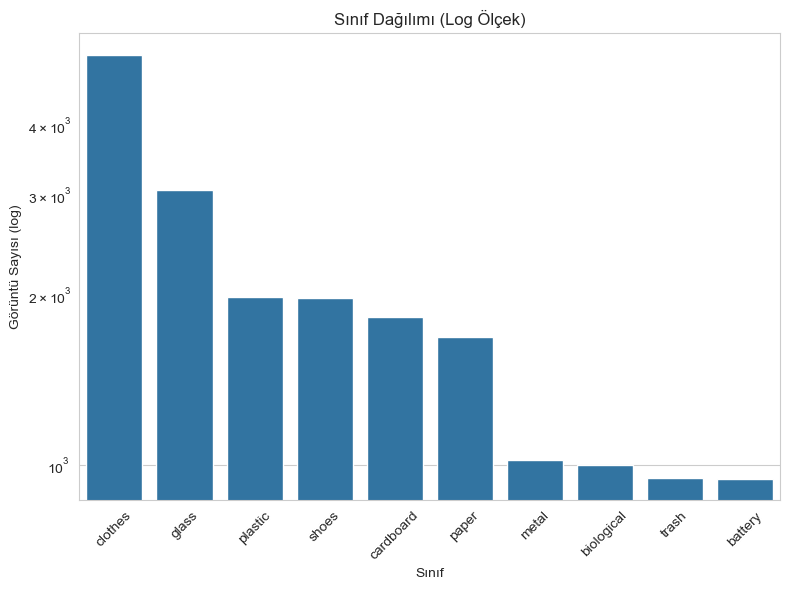

In [13]:
plt.figure()
sns.barplot(
    x="Class",
    y="Image_Count",
    data=class_distribution
)
plt.yscale("log")
plt.title("Sınıf Dağılımı (Log Ölçek)")
plt.xlabel("Sınıf")
plt.ylabel("Görüntü Sayısı (log)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [14]:
X = df["image_path"].values
y = df["label"].values


In [15]:
skf = StratifiedKFold(
    n_splits=config.N_SPLITS,
    shuffle=True,
    random_state=config.RANDOM_STATE
)


In [16]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1} seçildi")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    break


Fold 1 seçildi


In [17]:
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f"Train örnek sayısı: {len(train_df)}")
print(f"Test  örnek sayısı: {len(test_df)}")


Train örnek sayısı: 15809
Test  örnek sayısı: 3953


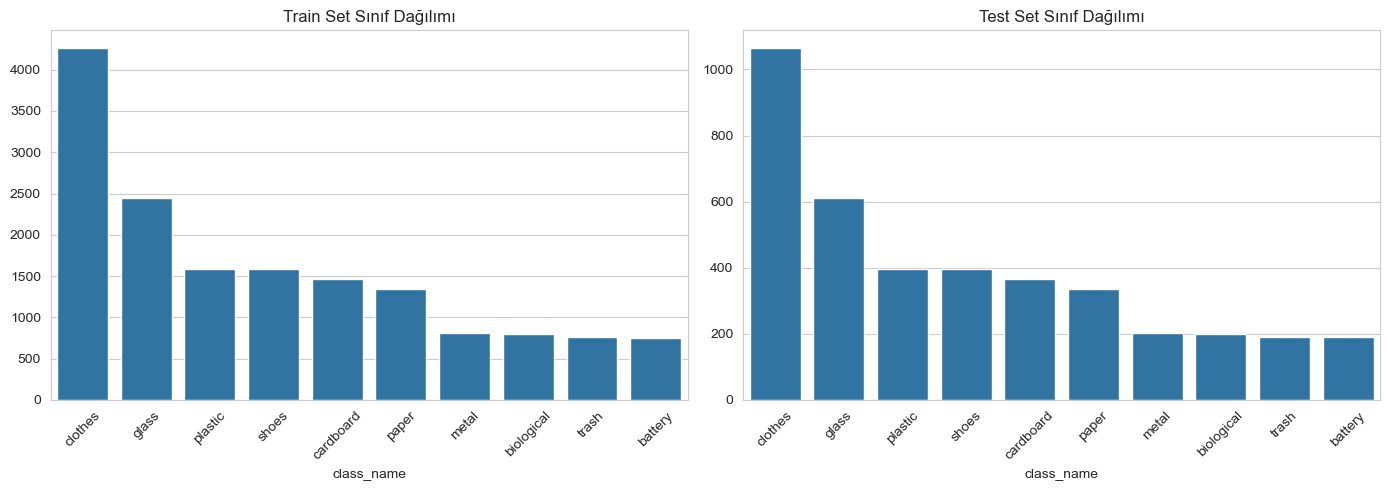

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grafik: Train Set
sns.barplot(
    x=train_df["class_name"].value_counts().index,
    y=train_df["class_name"].value_counts().values,
    ax=axes[0]
)
axes[0].set_title("Train Set Sınıf Dağılımı")
# Hatalı satır yerine bunu ekle:
axes[0].tick_params(axis='x', rotation=45)

# 2. Grafik: Test Set
sns.barplot(
    x=test_df["class_name"].value_counts().index,
    y=test_df["class_name"].value_counts().values,
    ax=axes[1]
)
axes[1].set_title("Test Set Sınıf Dağılımı")
# Hatalı satır yerine bunu ekle:
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


In [20]:
train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


In [21]:
val_test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


In [22]:
from PIL import Image

sample_path = train_df.iloc[0]["image_path"]
img = Image.open(sample_path).convert("RGB")

aug_img = train_transforms(img)
plain_img = val_test_transforms(img)

print("Augmented image shape:", aug_img.shape)
print("Validation image shape:", plain_img.shape)


Augmented image shape: torch.Size([3, 224, 224])
Validation image shape: torch.Size([3, 224, 224])


In [23]:
from PIL import Image

class TrashDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): image_path, label, class_name içermeli
            transform (callable): uygulanacak transformlar
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["image_path"]
        label = row["label"]
        class_name = row["class_name"]

        # Görüntüyü oku
        image = Image.open(image_path).convert("RGB")

        # Transform uygula
        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "label": label,
            "class_name": class_name,
            "image_path": image_path
        }


In [24]:
sample_dataset = TrashDataset(train_df, transform=train_transforms)
sample = sample_dataset[0]

print("Image shape:", sample["image"].shape)
print("Label:", sample["label"])
print("Class name:", sample["class_name"])
print("Image path:", sample["image_path"])


Image shape: torch.Size([3, 224, 224])
Label: 0
Class name: battery
Image path: C:\Users\Kardelen\Desktop\dlp\garbage-dataset\battery\battery_10.jpg


In [25]:
print("Train dataset size:", len(sample_dataset))
print("Test dataset size :", len(TrashDataset(test_df, val_test_transforms)))


Train dataset size: 15809
Test dataset size : 3953


In [26]:
from sklearn.model_selection import train_test_split

train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=config.RANDOM_STATE
)

print(f"Train (final) örnek sayısı: {len(train_df_split)}")
print(f"Validation örnek sayısı  : {len(val_df)}")


Train (final) örnek sayısı: 12647
Validation örnek sayısı  : 3162


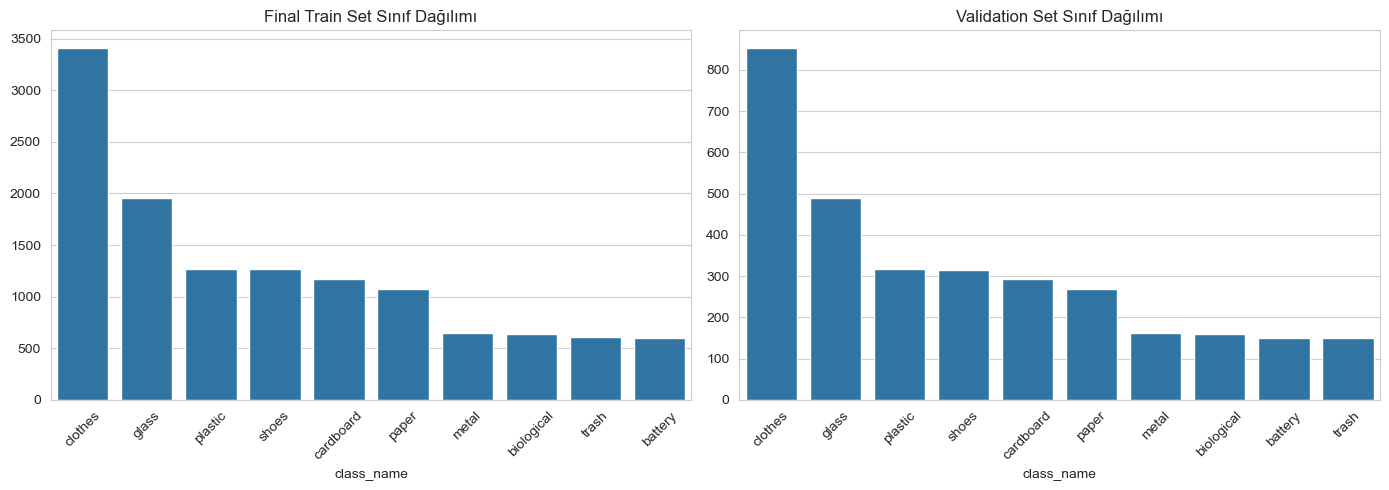

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=train_df_split["class_name"].value_counts().index,
    y=train_df_split["class_name"].value_counts().values,
    ax=axes[0]
)
axes[0].set_title("Final Train Set Sınıf Dağılımı")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=val_df["class_name"].value_counts().index,
    y=val_df["class_name"].value_counts().values,
    ax=axes[1]
)
axes[1].set_title("Validation Set Sınıf Dağılımı")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [28]:
train_dataset = TrashDataset(
    dataframe=train_df_split,
    transform=train_transforms
)

val_dataset = TrashDataset(
    dataframe=val_df,
    transform=val_test_transforms
)

test_dataset = TrashDataset(
    dataframe=test_df,
    transform=val_test_transforms
)


In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)


In [30]:
batch = next(iter(train_loader))

print("Batch image shape :", batch["image"].shape)
print("Batch label shape :", batch["label"].shape)


Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])


In [31]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df_split["label"]),
    y=train_df_split["label"]
)

class_weights


array([2.09387417, 1.9822884 , 1.0827911 , 0.37098856, 0.64558448,
       1.93675345, 1.17646512, 0.99661151, 0.99897314, 2.0869637 ])

In [32]:
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

class_weights_tensor


tensor([2.0939, 1.9823, 1.0828, 0.3710, 0.6456, 1.9368, 1.1765, 0.9966, 0.9990,
        2.0870], device='cuda:0')

In [33]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


In [34]:
for idx, weight in enumerate(class_weights):
    print(f"Sınıf: {idx_to_class[idx]:<10} → Ağırlık: {weight:.4f}")


Sınıf: battery    → Ağırlık: 2.0939
Sınıf: biological → Ağırlık: 1.9823
Sınıf: cardboard  → Ağırlık: 1.0828
Sınıf: clothes    → Ağırlık: 0.3710
Sınıf: glass      → Ağırlık: 0.6456
Sınıf: metal      → Ağırlık: 1.9368
Sınıf: paper      → Ağırlık: 1.1765
Sınıf: plastic    → Ağırlık: 0.9966
Sınıf: shoes      → Ağırlık: 0.9990
Sınıf: trash      → Ağırlık: 2.0870


In [35]:
def get_densenet121(num_classes, dropout_rate=0.5):
    model = models.densenet121(weights="DEFAULT")

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(512, num_classes)
    )

    return model


In [36]:
model = get_densenet121(
    num_classes=num_classes,
    dropout_rate=0.5
)

model = model.to(device)


In [37]:
trainable_params = sum(p.requires_grad for p in model.parameters())
total_params = sum(1 for _ in model.parameters())

print(f"Eğitilebilir parametreler: {trainable_params}")
print(f"Toplam parametreler     : {total_params}")


Eğitilebilir parametreler: 366
Toplam parametreler     : 366


In [38]:
#print(model)


In [39]:
# =========================
# Phase 1 - Head Training
# =========================

# 🔒 Backbone'u dondur
for param in model.features.parameters():
    param.requires_grad = False

# 🔓 Classifier açık
for param in model.classifier.parameters():
    param.requires_grad = True


In [40]:
def unfreeze_last_blocks(model, num_blocks=1):
    """
    DenseNet'te son denseblock'ları açar
    num_blocks: 1 → sadece denseblock4
                2 → denseblock3 + denseblock4
    """
    blocks = [
        model.features.denseblock1,
        model.features.denseblock2,
        model.features.denseblock3,
        model.features.denseblock4
    ]

    for block in blocks[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True


In [41]:
# Phase 1 - Head Training
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_phase1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase1,
    T_max=5,        # 5 epoch
    eta_min=1e-5
)


In [42]:
# Phase 2 - Fine Tuning
optimizer_phase2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,          # hatta 1e-5 de kullanılabilir
    weight_decay=1e-4
)

scheduler_phase2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase2,
    T_max=20,         # max 20 epoch
    eta_min=1e-6
)


In [43]:
def print_lr(optimizer):
    for param_group in optimizer.param_groups:
        print(f"Learning Rate: {param_group['lr']}")

print("Phase 1 LR:")
print_lr(optimizer_phase1)

print("\nPhase 2 LR:")
print_lr(optimizer_phase2)


Phase 1 LR:
Learning Rate: 0.001

Phase 2 LR:
Learning Rate: 0.0001


In [44]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / labels.size(0)


In [45]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [46]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    running_loss = 0.0
    running_acc = 0.0
    
    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    return running_loss / len(loader), running_acc / len(loader)


In [47]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    running_acc = 0.0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

    return running_loss / len(loader), running_acc / len(loader)


In [48]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []


In [49]:
EPOCHS_PHASE1 = 5 #epoch 5
early_stopping = EarlyStopping(patience=3)

best_val_loss = np.inf

for epoch in range(EPOCHS_PHASE1):
    print(f"\n🟢 Phase-1 Epoch {epoch+1}/{EPOCHS_PHASE1}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer_phase1, criterion, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler_phase1.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Best model kaydet
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("✅ Best model kaydedildi")

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("⛔ Early stopping (Phase-1)")
        break



🟢 Phase-1 Epoch 1/5


Train Loss: 0.8435 | Train Acc: 0.7567
Val   Loss: 0.4086 | Val   Acc: 0.8860
✅ Best model kaydedildi

🟢 Phase-1 Epoch 2/5


Train Loss: 0.5383 | Train Acc: 0.8364
Val   Loss: 0.3849 | Val   Acc: 0.8815
✅ Best model kaydedildi

🟢 Phase-1 Epoch 3/5


Train Loss: 0.4666 | Train Acc: 0.8570
Val   Loss: 0.3490 | Val   Acc: 0.8976
✅ Best model kaydedildi

🟢 Phase-1 Epoch 4/5


Train Loss: 0.4180 | Train Acc: 0.8769
Val   Loss: 0.3147 | Val   Acc: 0.9150
✅ Best model kaydedildi

🟢 Phase-1 Epoch 5/5


Train Loss: 0.3656 | Train Acc: 0.8899
Val   Loss: 0.3084 | Val   Acc: 0.9144
✅ Best model kaydedildi


In [50]:
unfreeze_last_blocks(model, num_blocks=1)


In [51]:
early_stopping = EarlyStopping(patience=5)


In [52]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []


In [53]:
EPOCHS_PHASE2 = 20 #epoch 20

for epoch in range(EPOCHS_PHASE2):
    print(f"\n🔵 Phase-2 Epoch {epoch+1}/{EPOCHS_PHASE2}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer_phase2, criterion, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)


    scheduler_phase2.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("✅ Best model güncellendi")

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("⛔ Early stopping (Phase-2)")
        break



🔵 Phase-2 Epoch 1/20


Train Loss: 0.3527 | Train Acc: 0.8934
Val   Loss: 0.2960 | Val   Acc: 0.9166
✅ Best model güncellendi

🔵 Phase-2 Epoch 2/20


Train Loss: 0.3522 | Train Acc: 0.8914
Val   Loss: 0.2917 | Val   Acc: 0.9153
✅ Best model güncellendi

🔵 Phase-2 Epoch 3/20


Train Loss: 0.3486 | Train Acc: 0.8933
Val   Loss: 0.3066 | Val   Acc: 0.9115

🔵 Phase-2 Epoch 4/20


Train Loss: 0.3497 | Train Acc: 0.8931
Val   Loss: 0.2890 | Val   Acc: 0.9179
✅ Best model güncellendi

🔵 Phase-2 Epoch 5/20


...

Train Loss: 0.3245 | Train Acc: 0.8984
Val   Loss: 0.2846 | Val   Acc: 0.9191

🔵 Phase-2 Epoch 10/20


Train Loss: 0.3264 | Train Acc: 0.8969
Val   Loss: 0.2880 | Val   Acc: 0.9182

🔵 Phase-2 Epoch 11/20


Train Loss: 0.3123 | Train Acc: 0.9016
Val   Loss: 0.2917 | Val   Acc: 0.9153

🔵 Phase-2 Epoch 12/20


Train Loss: 0.3185 | Train Acc: 0.9000
Val   Loss: 0.2763 | Val   Acc: 0.9198

🔵 Phase-2 Epoch 13/20


Train Loss: 0.3124 | Train Acc: 0.8997
Val   Loss: 0.2854 | Val   Acc: 0.9188
⛔ Early stopping (Phase-2)


In [54]:
epochs = range(1, len(train_losses) + 1)


In [55]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()


C:\Users\Kardelen\AppData\Local\Temp\ipykernel_23172\1166263760.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_loc

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [56]:
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test Evaluation"):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)


Test Evaluation: 100%|███████████████████████████████████████████████████████████████| 124/124 [02:05<00:00,  1.01s/it]


In [57]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.9135


In [58]:
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")


Macro F1    : 0.8902
Weighted F1 : 0.9141


In [59]:
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"Cohen’s Kappa: {kappa:.4f}")


Cohen’s Kappa: 0.8995


In [60]:
roc_auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="macro"
)

print(f"ROC AUC (OvR, Macro): {roc_auc:.4f}")


ROC AUC (OvR, Macro): 0.9948


In [61]:
pr_auc_scores = []

for class_idx in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        (all_labels == class_idx).astype(int),
        all_probs[:, class_idx]
    )
    pr_auc_scores.append(auc(recall, precision))

macro_pr_auc = np.mean(pr_auc_scores)
print(f"PR AUC (Macro): {macro_pr_auc:.4f}")


PR AUC (Macro): 0.9586


In [62]:
top1_acc = top_k_accuracy_score(
    all_labels,
    all_probs,
    k=1
)

top5_acc = top_k_accuracy_score(
    all_labels,
    all_probs,
    k=5
)

print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")


Top-1 Accuracy: 0.9135
Top-5 Accuracy: 0.9967


In [63]:
results_summary = {
    "Accuracy": test_accuracy,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "ROC AUC": roc_auc,
    "PR AUC": macro_pr_auc,
    "Cohen Kappa": kappa,
    "Top-1 Acc": top1_acc,
    "Top-5 Acc": top5_acc
}

pd.DataFrame(results_summary, index=["DenseNet121"])


,Accuracy,Macro F1,Weighted F1,ROC AUC,PR AUC,Cohen Kappa,Top-1 Acc,Top-5 Acc
DenseNet121,0.913483,0.890231,0.914134,0.994786,0.958622,0.899475,0.913483,0.996711


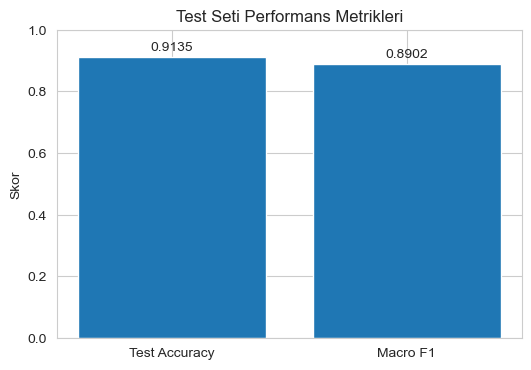

In [64]:
import matplotlib.pyplot as plt

metrics = ["Test Accuracy", "Macro F1"]
values = [test_accuracy, macro_f1]

plt.figure(figsize=(6,4))
bars = plt.bar(metrics, values)
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.4f}",
        ha="center"
    )

plt.title("Test Seti Performans Metrikleri")
plt.ylabel("Skor")
plt.show()


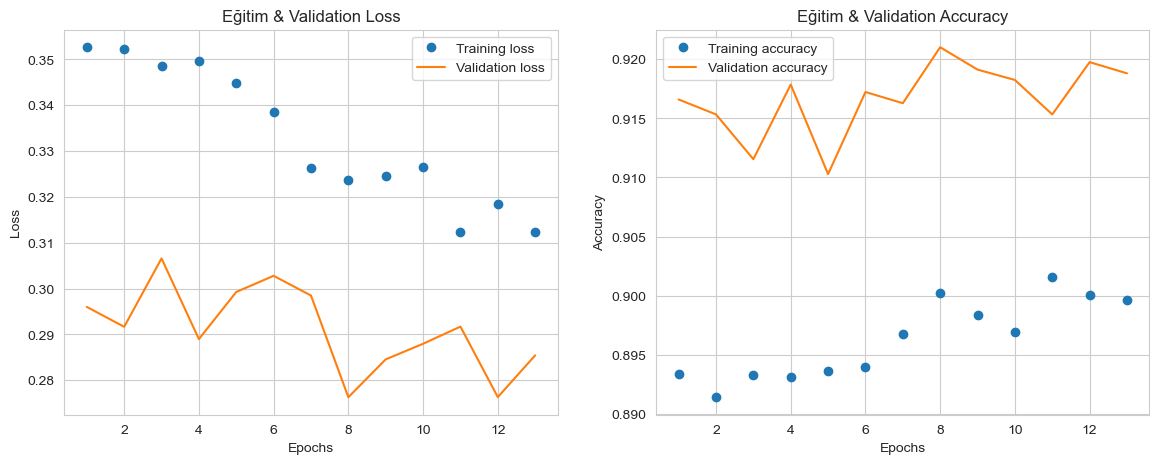

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# LOSS GRAFİĞİ
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'o', label="Training loss")
plt.plot(epochs, val_losses, label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Eğitim & Validation Loss")
plt.legend()

# ACCURACY GRAFİĞİ
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, 'o', label="Training accuracy")
plt.plot(epochs, val_accs, label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Eğitim & Validation Accuracy")
plt.legend()

plt.show()


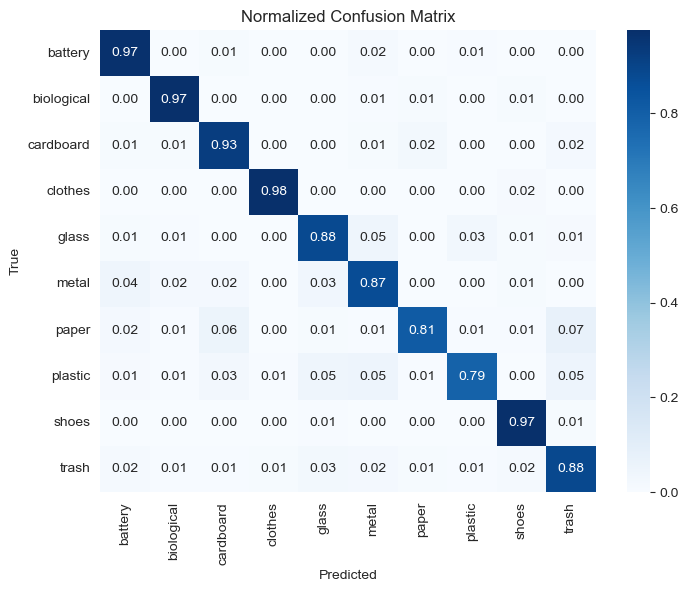

In [66]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()


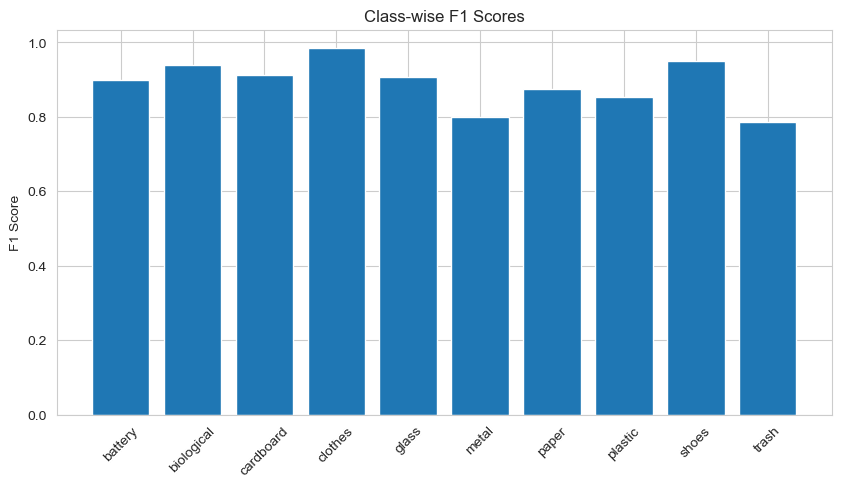

In [67]:
f1_per_class = f1_score(
    all_labels,
    all_preds,
    average=None
)

plt.figure(figsize=(10, 5))
plt.bar(class_names, f1_per_class)
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.title("Class-wise F1 Scores")
plt.show()


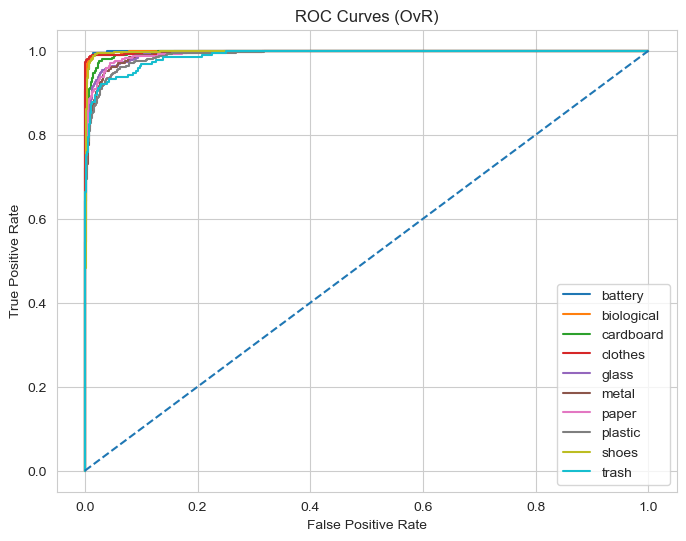

In [68]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        (all_labels == i).astype(int),
        all_probs[:, i]
    )
    plt.plot(fpr, tpr, label=f"{class_names[i]}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (OvR)")
plt.legend()
plt.show()


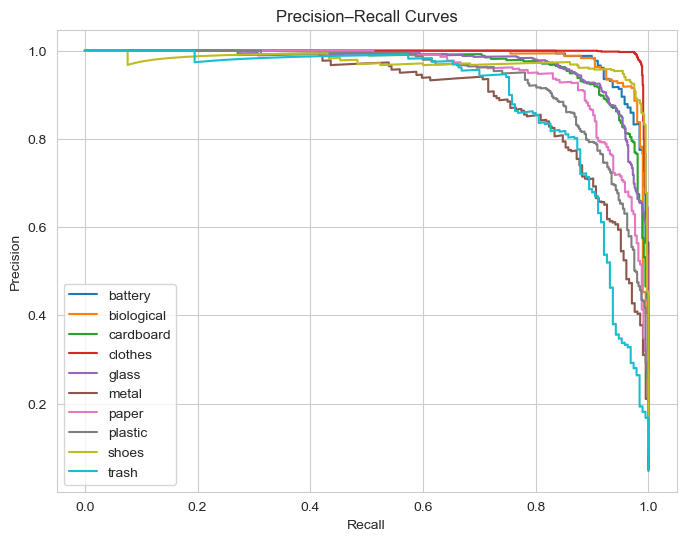

In [69]:
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        (all_labels == i).astype(int),
        all_probs[:, i]
    )
    plt.plot(recall, precision, label=f"{class_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.show()


In [70]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    roc_auc_score, 
    average_precision_score, 
    cohen_kappa_score
)

general_results = pd.DataFrame({
    "Model": ["DenseNet121"],
    "Accuracy": [accuracy_score(all_labels, all_preds)],
    "Macro F1": [f1_score(all_labels, all_preds, average="macro")],
    "Weighted F1": [f1_score(all_labels, all_preds, average="weighted")],
    "ROC AUC": [roc_auc_score(
        np.eye(num_classes)[all_labels],
        all_probs,
        average="macro",
        multi_class="ovr"
    )],
    "PR AUC": [average_precision_score(
        np.eye(num_classes)[all_labels],
        all_probs,
        average="macro"
    )],
    "Cohen Kappa": [cohen_kappa_score(all_labels, all_preds)]
})

general_results


,Model,Accuracy,Macro F1,Weighted F1,ROC AUC,PR AUC,Cohen Kappa
0,DenseNet121,0.913483,0.890231,0.914134,0.994786,0.958692,0.899475


In [71]:
from sklearn.metrics import classification_report

class_report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

class_df = pd.DataFrame(class_report).transpose()
class_df[["precision", "recall", "f1-score"]]



,precision,recall,f1-score
battery,0.839450,0.968254,0.899263
biological,0.902778,0.975000,0.937500
cardboard,0.896552,0.926027,0.911051
clothes,0.994258,0.975587,0.984834
glass,0.934142,0.880719,0.906644
metal,0.738589,0.872549,0.800000
paper,0.947917,0.812500,0.875000
plastic,0.928783,0.788413,0.852861
shoes,0.923261,0.974684,0.948276
trash,0.708861,0.884211,0.786885


In [72]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
def predict_single_image(model, image, device):
    model.eval()
    
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)  # [1, C, H, W]
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        
        confidence, pred_class = torch.max(probs, dim=1)
        
    return pred_class.item(), confidence.item()


In [73]:
def visualize_random_predictions(
    model,
    dataset,
    class_names,
    device,
    num_images=8
):
    indices = random.sample(range(len(dataset)), num_images)
    
    plt.figure(figsize=(16, 8))
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        image = sample["image"]
        true_label = sample["label"]
        
        pred_label, confidence = predict_single_image(
            model, image, device
        )
        
        # Normalize geri al (imshow için)
        img = image.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())
        
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(img)
        plt.axis("off")
        
        color = "green" if pred_label == true_label else "red"
        
        plt.title(
            f"GT: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Conf: {confidence:.2f}",
            color=color,
            fontsize=10
        )
    
    plt.suptitle("Rastgele Test Görselleri Üzerinde Model Tahminleri", fontsize=14)
    plt.tight_layout()
    plt.show()


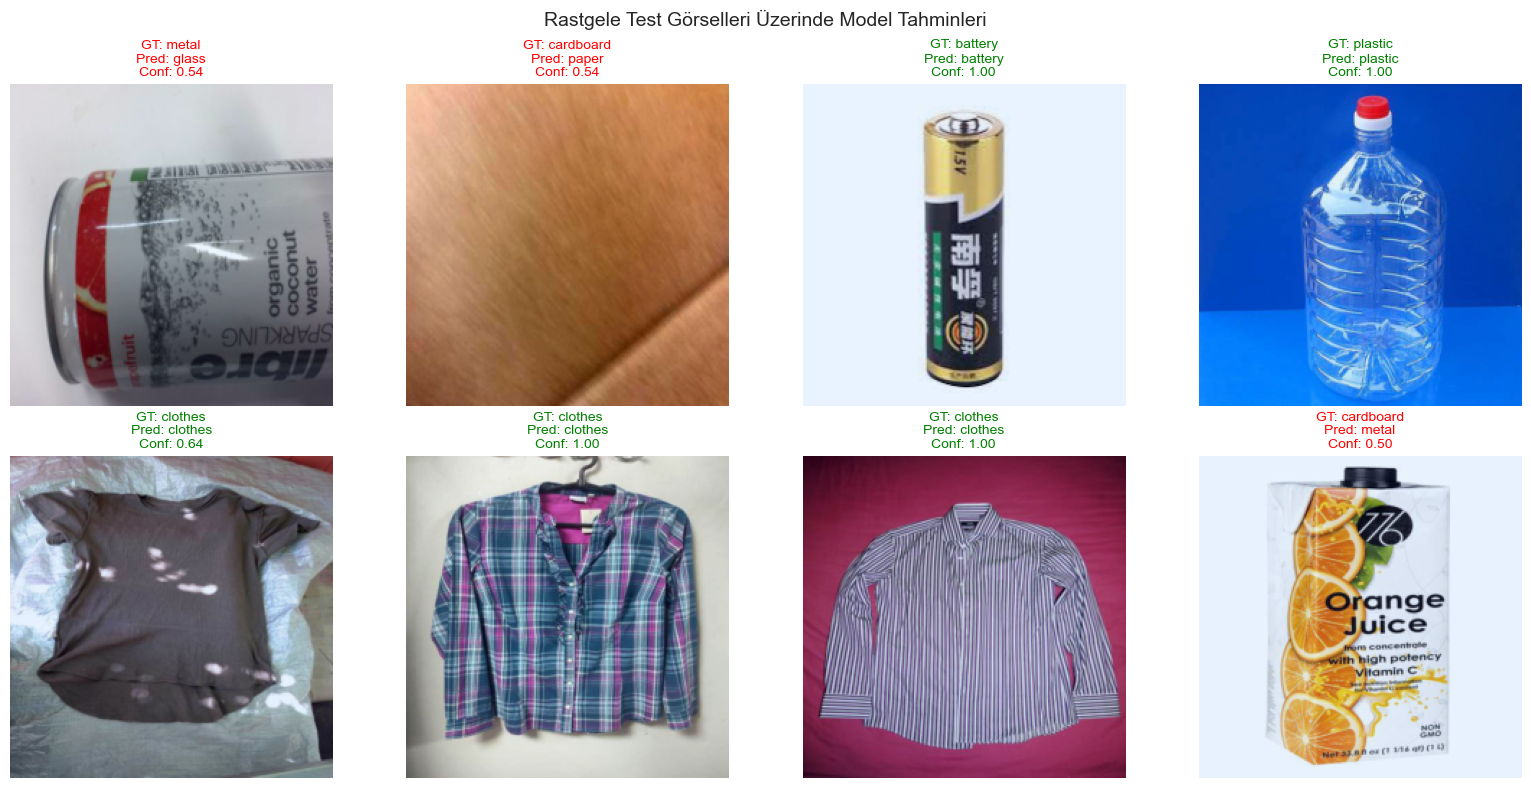

In [74]:
visualize_random_predictions(
    model=model,
    dataset=test_dataset,
    class_names=class_names,
    device=device,
    num_images=8
)


In [75]:
def visualize_specific_class(
    model,
    dataset,
    target_class,
    class_names,
    device,
    num_images=6
):
    indices = [
        i for i in range(len(dataset))
        if dataset[i]["label"] == target_class
    ]
    
    selected = random.sample(indices, min(num_images, len(indices)))
    
    plt.figure(figsize=(14, 6))
    
    for i, idx in enumerate(selected):
        sample = dataset[idx]
        image = sample["image"]
        true_label = sample["label"]
        
        pred_label, confidence = predict_single_image(
            model, image, device
        )
        
        img = image.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())
        
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(img)
        plt.axis("off")
        
        color = "green" if pred_label == true_label else "red"
        
        plt.title(
            f"GT: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Conf: {confidence:.2f}",
            color=color
        )
    
    plt.suptitle(
        f"Sınıf Analizi: {class_names[target_class]}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


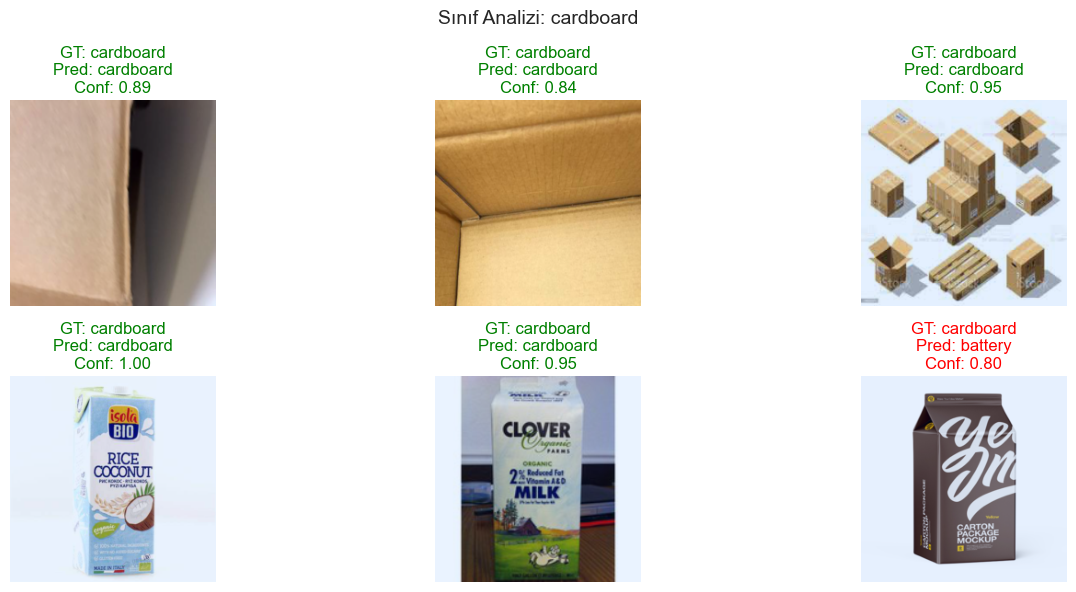

In [76]:
visualize_specific_class(
    model,
    test_dataset,
    target_class=2,  # örn: cam
    class_names=class_names,
    device=device
)
